In [86]:
%load_ext autoreload
%autoreload 2

from src.dynamical_systems import *
from src.SINDyModel import *
from src.derivatives import *
from src.helpers import *

import matplotlib.pyplot as plt
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [119]:
rhs = generate_lotka_volterra_rhs(1, 0.1, 1.5, 0.75)
# rhs = generate_van_der_pol_rhs(0.01)

x0 = (10, 5)
dt = 0.01
t_span = (0, 100)

t_eval = np.arange(t_span[0], t_span[1] + dt, dt)

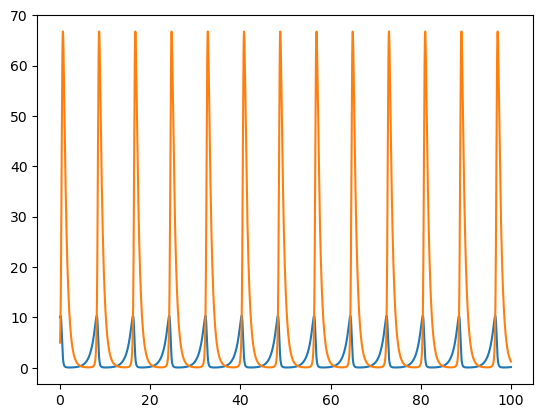

In [120]:
x_train = generate_training_data(rhs, x0, t_eval)

plt.plot(t_eval, x_train.T)
# plt.legend('xy')
plt.show()

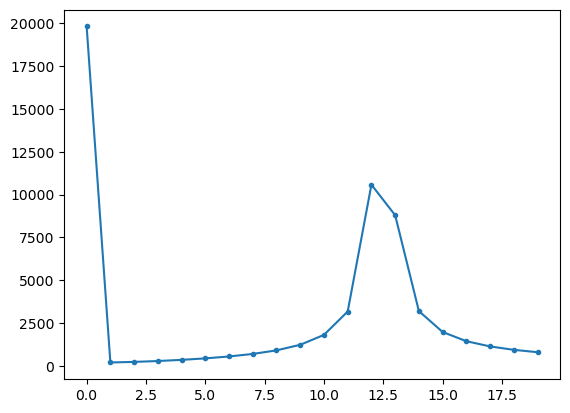

In [121]:
fft = np.fft.fft(x_train[0])

plt.plot(np.abs(fft)[:20], '.-')

# for i in range(50):
#     print(f'{i}: {np.abs(fft[i])}')

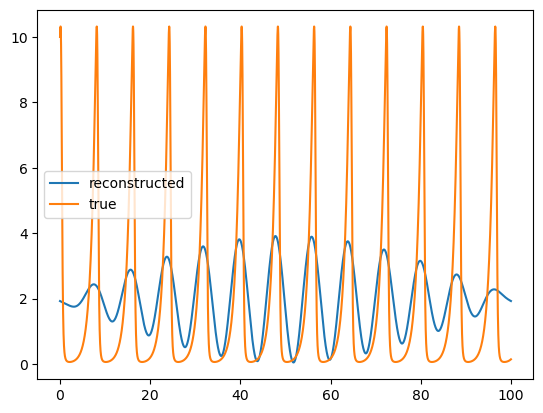

In [126]:
# sig = np.zeros_like(fft)
# for i in range(2):
    # sig += 1/len(fft)*np.abs(fft[i])*np.cos(2*np.pi*i*t_eval + np.angle(fft[i]))

fft_trunc = np.zeros_like(fft)

n = 9
# fft_trunc[:n] = fft[:n]

idx = np.array([0, 12, 13])
fft_trunc[idx] = fft[idx]


sig_trunc = np.fft.ifft(fft_trunc)

plt.plot(t_eval, sig_trunc, label='reconstructed')
plt.plot(t_eval, x_train[0], label='true')
plt.legend()